add a baseline information about the customer that the company knows about the system, in a non-contractual system, there may be a history on the customer, so they purchase large amounts, if contractual system, you could probably assign some priority. for a contractual system, if you have a 100 customers calling, then you have capacity concerns of 10 human agents.

**Split this into two cases of the representative agent if you have no information. If you know more about them, then you can do this more informed analysis.**

**reformat the paper the international journal production of economics**

**focus on robust optimization, use the simulated annealing for the robust optimizaiton (which is basically just stochastic gradient descent)**
(there isnt any optimization due to uncertainties)

https://www.kaggle.com/datasets/woody123/cdnow-dataset


some of the 100 people are higher and lower priority, you can have a system to optimize of sending AI or chatbot, the highest priority will be optimized.

like, do you think higher priority customers can wait in the meantime. we can find a value-weighted priority queue.

going back to when the idea was just r_1 and r_2 probabilitistic from the residual lifetime value, we can have optimization from that using the robust optimization (its when you know about the history)

In [36]:
!pip install --q pathos
from __future__ import annotations

import multiprocessing as mp
from pathos.multiprocessing import ProcessingPool as Pool
from dataclasses import dataclass, replace
from typing import Callable

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


My goal for this notebook is:
* To generate a series of curves analyzing system behavior under different parameter settings (e.g., varying r_1 and r_2), including producing two graphs for comparison;
    * To implement multiprocessing (avoiding standard for-loops) to efficiently compute these simulations;


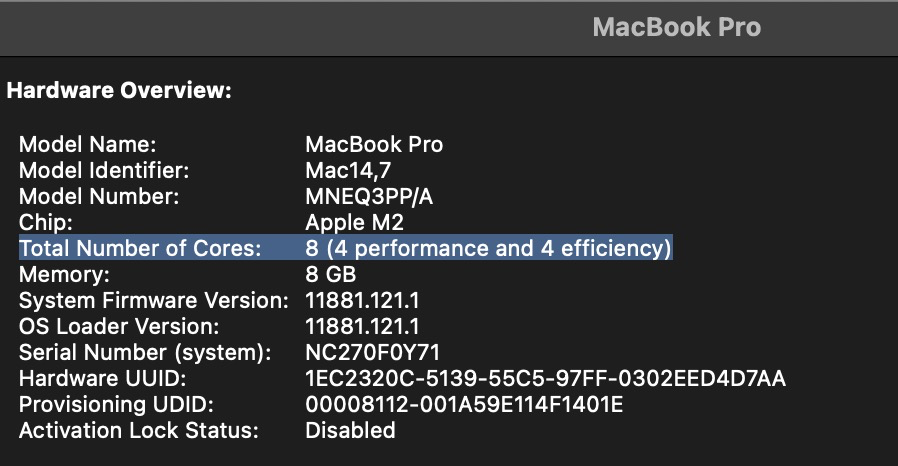

Thew code below is to generate level sets for the queueing system by sweeping over the possible combinations of $(r_1, r_2)$ using multiprocessing.

In [37]:
# Helper Functions

@dataclass
class QueueingSystemParams:
    arrival_rate: float
    num_servers: int
    service_rate: float
    class2_arrival_rate: float
    class1_reward: float
    class2_reward: float
    outsourcing_cost: float
    congestion_sensitivity: float
    max_queue_length: int
    convergence_tolerance: float
    max_iterations: int


def build_state_space(params: QueueingSystemParams):
    return list(range(-params.num_servers, params.max_queue_length + 1))


def get_state_index(state: int, params: QueueingSystemParams):
    return state + params.num_servers


def class1_decision_value(state, value_function, params):
    index = get_state_index(state, params)
    if state < 0:
        return value_function[index] + params.class1_reward
    next_queue_value = (
        value_function[index + 1] if index + 1 < len(value_function) else value_function[index]
    )
    outsource_value = value_function[index] - params.outsourcing_cost
    return max(next_queue_value, outsource_value)


def class2_decision_value(state, value_function, params):
    index = get_state_index(state, params)
    if state < 0:
        idle_value = value_function[index]
        initiate_service_value = (
            value_function[index + 1] if index + 1 < len(value_function) else value_function[index]
        ) + params.class2_reward
        return max(idle_value, initiate_service_value)
    return value_function[index]


def fil_waiting_time_operator(state, value_function, params):
    if state <= 0:
        return value_function[get_state_index(state, params)]
    x = state
    lam = params.arrival_rate
    gamma = params.class2_arrival_rate
    p = lam / (lam + gamma)
    q = gamma / (lam + gamma)
    value = 0.0
    for h in range(x):
        prob = p * (q ** h)
        next_state = max(0, x - h)
        value += prob * value_function[get_state_index(next_state, params)]
    value += (q ** x) * value_function[get_state_index(0, params)]
    return value


def bellman_update_apriori(value_function, params):
    normalization = params.arrival_rate + params.num_servers * params.service_rate
    arrival_prob = params.arrival_rate / normalization
    service_prob = params.service_rate / normalization
    new_value_function = np.zeros_like(value_function)
    state_space = build_state_space(params)
    for i, state in enumerate(state_space):
        busy_servers = min(params.num_servers, params.num_servers + state)
        effective_service_rate = busy_servers * service_prob
        class1_value = class1_decision_value(state, value_function, params)
        class2_value = class2_decision_value(state, value_function, params)
        previous_service_value = (
            class2_decision_value(state - 1, value_function, params)
            if state - 1 >= -params.num_servers else 0.0
        )
        congestion_adjustment = (
            params.class1_reward
            * (1 - params.congestion_sensitivity * state / (params.num_servers * service_prob))
            if state > 0 else 0.0
        )
        new_value_function[i] = (
            arrival_prob * class1_value
            + effective_service_rate * (previous_service_value + congestion_adjustment)
            + (1 - arrival_prob - effective_service_rate) * class2_value
        )
    return new_value_function


def bellman_update_aposteriori(value_function, params):
    normalization = (
        params.arrival_rate
        + params.num_servers * params.service_rate
        + params.class2_arrival_rate
    )
    arrival_prob = params.arrival_rate / normalization
    service_prob = params.service_rate / normalization
    class2_prob = params.class2_arrival_rate / normalization
    new_value_function = np.zeros_like(value_function)
    state_space = build_state_space(params)
    for i, state in enumerate(state_space):
        if state <= 0:
            class1_value = (
                value_function[i] + params.class1_reward
                if state < 0
                else class1_decision_value(state, value_function, params)
            )
            class2_value = class2_decision_value(state, value_function, params)
            effective_service_rate = (params.num_servers + state) * service_prob
            previous_service_value = (
                class2_decision_value(state - 1, value_function, params)
                if state - 1 >= -params.num_servers else 0.0
            )
            new_value_function[i] = (
                arrival_prob * class1_value
                + effective_service_rate * previous_service_value
                + (1 - arrival_prob - effective_service_rate) * class2_value
            )
        else:
            class1_value = class1_decision_value(state, value_function, params)
            fil_value = fil_waiting_time_operator(state, value_function, params)
            class2_value = class2_decision_value(state, value_function, params)
            congestion_adjustment = params.class1_reward * (
                1 - params.congestion_sensitivity * state / max(class2_prob, 1e-9)
            )
            new_value_function[i] = (
                class2_prob * class1_value
                + params.num_servers * service_prob * (fil_value + congestion_adjustment)
                + (1 - class2_prob - params.num_servers * service_prob) * class2_value
            )
    return new_value_function


def solve(bellman_fn: Callable, params: QueueingSystemParams):
    V = np.zeros(len(build_state_space(params)))
    history = []
    for _ in range(params.max_iterations):
        V_next = bellman_fn(V, params)
        error = float(np.max(np.abs(V_next - V)))
        history.append(error)
        V = V_next
        if error < params.convergence_tolerance:
            break
    return V, history

In [4]:
# Running Functions (Main Functions)

def _run_apriori(args: tuple) -> tuple:
    """
    Worker for a priori Bellman.
    Returns (r1, r2, value_function, convergence_history).
    """
    base_params, r1, r2 = args
    params = replace(base_params, class1_reward=r1, class2_reward=r2)
    V, hist = solve(bellman_update_apriori, params)
    return r1, r2, V, hist


def _run_aposteriori(args: tuple) -> tuple:
    """
    Worker for a posteriori Bellman.
    Returns (r1, r2, value_function, convergence_history).
    """
    base_params, r1, r2 = args
    params = replace(base_params, class1_reward=r1, class2_reward=r2)
    V, hist = solve(bellman_update_aposteriori, params)
    return r1, r2, V, hist

In [5]:
# Contains the actual multiprocesing
def extract_policy(
    value_function: np.ndarray,
    params: QueueingSystemParams,
) -> dict:
    """
    Given a converged value function, returns the optimal decision at every
    state and the key threshold indices.
 
    Returns
    -------
    dict with keys:
        "class1_actions"   : list of "QUEUE" | "OUTSOURCE" | "ACCEPT" per state
        "class2_actions"   : list of "INITIATE" | "IDLE" per state
        "outsource_thresh" : lowest x >= 0 where Class 1 chooses OUTSOURCE
                             (None if never outsourced within queue range)
        "initiate_thresh"  : highest x < 0 where Class 2 chooses INITIATE
                             (None if never initiated)
    """
    state_space = build_state_space(params)
    V = value_function
 
    class1_actions = []
    class2_actions = []
 
    outsource_thresh = None   # first state where outsourcing is optimal
    initiate_thresh  = None   # last (highest) idle state where initiation wins
 
    for state in state_space:
        idx = get_state_index(state, params)
 
        # ── Class 1 decision ───────────────────────────────────────────────
        if state < 0:
            # Idle server: always accept
            class1_actions.append("ACCEPT")
        else:
            next_q_val  = V[idx + 1] if idx + 1 < len(V) else V[idx]
            outsource_val = V[idx] - params.outsourcing_cost
            if next_q_val >= outsource_val:
                class1_actions.append("QUEUE")
            else:
                class1_actions.append("OUTSOURCE")
                if outsource_thresh is None:
                    outsource_thresh = state   # first time we outsource
 
        # ── Class 2 decision ───────────────────────────────────────────────
        if state < 0:
            idle_val     = V[idx]
            initiate_val = (V[idx + 1] if idx + 1 < len(V) else V[idx]) + params.class2_reward
            if initiate_val >= idle_val:
                class2_actions.append("INITIATE")
                initiate_thresh = state        # keep updating → last idle state
            else:
                class2_actions.append("IDLE")
        else:
            class2_actions.append("IDLE")
 
    return {
        "state_space"      : state_space,
        "class1_actions"   : class1_actions,
        "class2_actions"   : class2_actions,
        "outsource_thresh" : outsource_thresh,
        "initiate_thresh"  : initiate_thresh,
    }


def _worker_apriori(args: tuple) -> tuple:
    base_params, r1, r2 = args
    params = replace(base_params, class1_reward=r1, class2_reward=r2)
    V, _ = solve(bellman_update_apriori, params)
    pol  = extract_policy(V, params)
    return r1, r2, pol["outsource_thresh"], pol["initiate_thresh"]
 
 
def _worker_aposteriori(args: tuple) -> tuple:
    base_params, r1, r2 = args
    params = replace(base_params, class1_reward=r1, class2_reward=r2)
    V, _ = solve(bellman_update_aposteriori, params)
    pol  = extract_policy(V, params)
    return r1, r2, pol["outsource_thresh"], pol["initiate_thresh"]

def run_sweep_parallel(
    worker_fn: Callable,
    base_params: QueueingSystemParams,
    r1_values: list[float],
    r2_values: list[float],
    n_workers: int | None = None,
) -> list[tuple]:
    """
    Runs `worker_fn` over every (r1, r2) combination in parallel.
    """
    job_args = [
        (base_params, r1, r2)
        for r1 in r1_values
        for r2 in r2_values
    ]
    
    # Pathos Pool handles Notebook-defined functions much better
    with Pool(processes=n_workers) as pool:
        results = pool.map(worker_fn, job_args)
    return results

NameError: name 'np' is not defined

In [3]:
def _build_grid(
    results: list[tuple],
    r1_values: list[float],
    r2_values: list[float],
    field: str,          # "outsource" or "initiate"
) -> np.ndarray:
    """
    Assembles a 2-D array shaped (len(r1_values), len(r2_values)).
    Rows = r1, columns = r2.
    Missing/None entries are replaced with NaN.
    """
    lookup = {
        (round(r1, 8), round(r2, 8)): (ot, it)
        for r1, r2, ot, it in results
    }
    grid = np.full((len(r1_values), len(r2_values)), np.nan)
    for i, r1 in enumerate(r1_values):
        for j, r2 in enumerate(r2_values):
            entry = lookup.get((round(r1, 8), round(r2, 8)))
            if entry is None:
                continue
            val = entry[0] if field == "outsource" else entry[1]
            grid[i, j] = val if val is not None else np.nan
    return grid


NameError: name 'np' is not defined

In [6]:
def plot_policy_curves(
    results: list[tuple],
    r1_values: list[float],
    r2_values: list[float],
    title_prefix: str,
    filepath_prefix: str,
) -> None:
    """
    Produces two figures:
 
    Figure A  —  2 by 2 panel
        Top-left   : heatmap of outsourcing threshold x* over (r1, r2)
        Top-right  : heatmap of initiation threshold x** over (r1, r2)
        Bottom-left : line plot of x* vs r1, one line per r2
        Bottom-right: line plot of x* vs r2, one line per r1
    """
    grid_out  = _build_grid(results, r1_values, r2_values, "outsource")
    grid_init = _build_grid(results, r1_values, r2_values, "initiate")
 
    # ── Figure: heatmaps ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{title_prefix} — Optimal Decision Thresholds", fontsize=13, fontweight="bold")
 
    r1_arr = np.array(r1_values)
    r2_arr = np.array(r2_values)
 
    for ax, grid, label, cmap in [
        (axes[0], grid_out,  "Class 1 outsourcing threshold  x*\n(queue → outsource crossover)",  "plasma"),
        (axes[1], grid_init, "Class 2 initiation threshold  x**\n(highest idle state with proactive service)", "viridis"),
    ]:
        im = ax.imshow(
            grid,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            extent=[r2_arr[0], r2_arr[-1], r1_arr[0], r1_arr[-1]],
        )
        ax.set_xlabel("r₂  (Class 2/Live Agent reward)", fontsize=10)
        ax.set_ylabel("r₁  (Class 1/Chatbot reward)", fontsize=10)
        ax.set_title(label, fontsize=10)
        cb = fig.colorbar(im, ax=ax, shrink=0.85)
        cb.set_label("State x", fontsize=9)
 
        # Annotate each cell
        for i, r1 in enumerate(r1_values):
            for j, r2 in enumerate(r2_values):
                val = grid[i, j]
                if not np.isnan(val):
                    ax.text(
                        r2, r1, f"{int(val)}",
                        ha="center", va="center",
                        fontsize=8, color="white",
                        fontweight="bold",
                    )
 
    fig.tight_layout()
    fig.show()
    plt.close(fig)
 
    # ── Figure: line plots ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f"{title_prefix} — Outsourcing Threshold  x*  vs Reward Parameters",
        fontsize=13, fontweight="bold",
    )
 
    cmap_r2 = plt.cm.viridis
    cmap_r1 = plt.cm.plasma
 
    # Left: x* vs r1, one line per r2
    ax = axes[0]
    for k, r2 in enumerate(r2_values):
        color = cmap_r2(k / max(len(r2_values) - 1, 1))
        y_vals = grid_out[:, k]           # rows = r1 index
        ax.plot(r1_arr, y_vals, "o-", color=color, lw=1.8, ms=5, label=f"r₂={r2:.1f}")
    ax.set_xlabel("r₁  (Class 1/Chatbot reward)", fontsize=10)
    ax.set_ylabel("Outsourcing threshold  x*", fontsize=10)
    ax.set_title("x*  as r₁ varies  (per r₂)", fontsize=11)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
 
    # Right: x* vs r2, one line per r1
    ax = axes[1]
    for k, r1 in enumerate(r1_values):
        color = cmap_r1(k / max(len(r1_values) - 1, 1))
        y_vals = grid_out[k, :]           # cols = r2 index
        ax.plot(r2_arr, y_vals, "s-", color=color, lw=1.8, ms=5, label=f"r₁={r1:.1f}")
    ax.set_xlabel("r₂  (Class 2/Live Agent reward)", fontsize=10)
    ax.set_ylabel("Outsourcing threshold  x*", fontsize=10)
    ax.set_title("x*  as r₂ varies  (per r₁)", fontsize=11)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
 
    fig.tight_layout()
    plt.show()
    plt.close(fig)


Let's run the actual thing.

Running a priori sweep …


/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_72089/2256237306.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


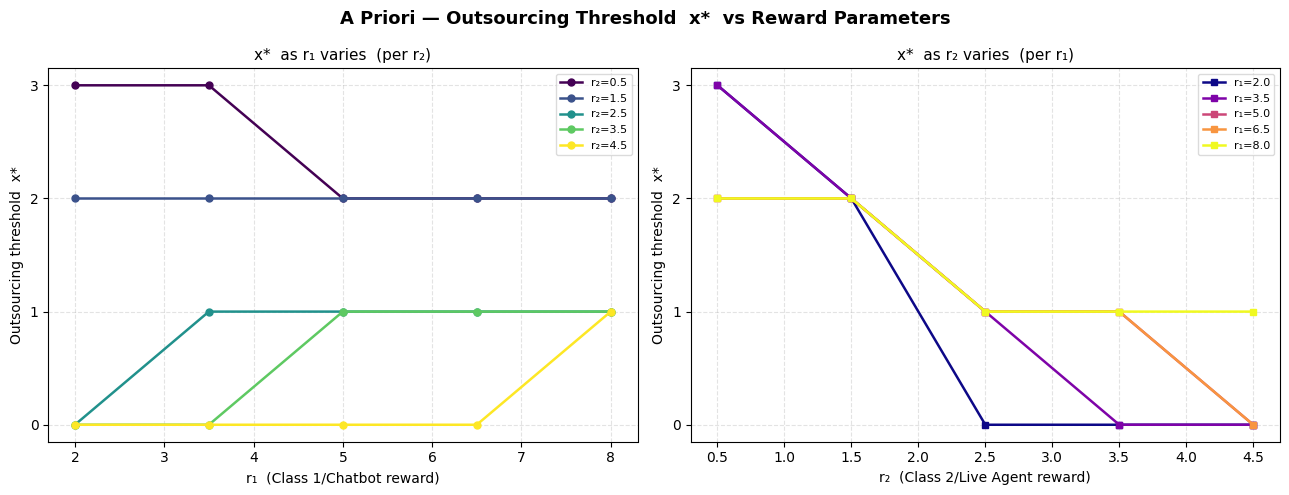

Running a posteriori sweep …


/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_72089/2256237306.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


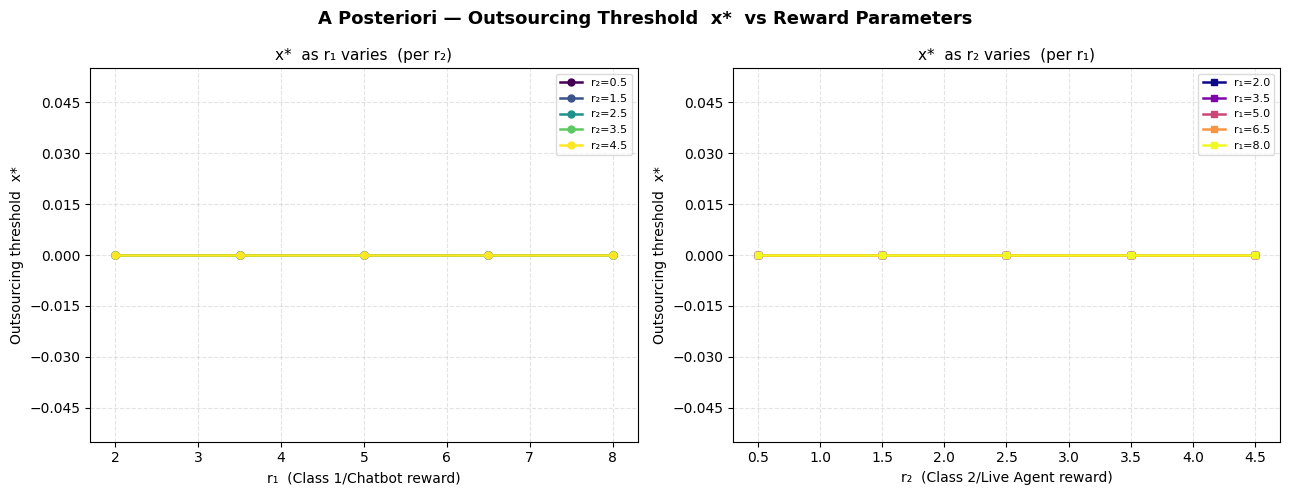

In [49]:
BASE = QueueingSystemParams(
    arrival_rate=0.6,
    num_servers=2,
    service_rate=0.5,
    class2_arrival_rate=0.3,
    class1_reward=5.0,
    class2_reward=2.0,
    outsourcing_cost=1.5,
    congestion_sensitivity=0.1,
    max_queue_length=15,
    convergence_tolerance=1e-6,
    max_iterations=2000,
)

R1_VALUES = [2.0, 3.5, 5.0, 6.5, 8.0]
R2_VALUES = [0.5, 1.5, 2.5, 3.5, 4.5]

print("Running a priori sweep …")
res_ap = run_sweep_parallel(_worker_apriori, BASE, R1_VALUES, R2_VALUES)
plot_policy_curves(res_ap, R1_VALUES, R2_VALUES,
                    title_prefix="A Priori",
                    filepath_prefix="policy_apriori")

print("Running a posteriori sweep …")
res_post = run_sweep_parallel(_worker_aposteriori, BASE, R1_VALUES, R2_VALUES)
plot_policy_curves(res_post, R1_VALUES, R2_VALUES,
                    title_prefix="A Posteriori",
                    filepath_prefix="policy_aposteriori")

The outsourcing threshold $x^* = 1$ for literally every single (r1, r2) combination tested, so that means varying r1 and r2 in your current range has zero effect on the decision policy. The system always outsources the moment there's 1 customer already in queue, no matter what the rewards are.

In [7]:
BASE = QueueingSystemParams(
    arrival_rate=0.6,
    num_servers=5,
    service_rate=0.5,
    class2_arrival_rate=0.3,
    class1_reward=5.0,
    class2_reward=2.0,
    outsourcing_cost=1.5,
    congestion_sensitivity=0.1,
    max_queue_length=15,
    convergence_tolerance=1e-6,
    max_iterations=2000,
)

R1_VALUES = [2.0, 3.5, 5.0, 6.5, 8.0]
R2_VALUES = [0.5, 1.5, 2.5, 3.5, 4.5]


print("Running a priori sweep …")
res_ap = run_sweep_parallel(_worker_apriori, BASE, R1_VALUES, R2_VALUES)
plot_policy_curves(res_ap, R1_VALUES, R2_VALUES,
                    title_prefix="A Priori",
                    filepath_prefix="policy_apriori")

print("Running a posteriori sweep …")
res_post = run_sweep_parallel(_worker_aposteriori, BASE, R1_VALUES, R2_VALUES)
plot_policy_curves(res_post, R1_VALUES, R2_VALUES,
                    title_prefix="A Posteriori",
                    filepath_prefix="policy_aposteriori")

NameError: name 'QueueingSystemParams' is not defined

Running a priori sweep …


/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_72089/2256237306.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


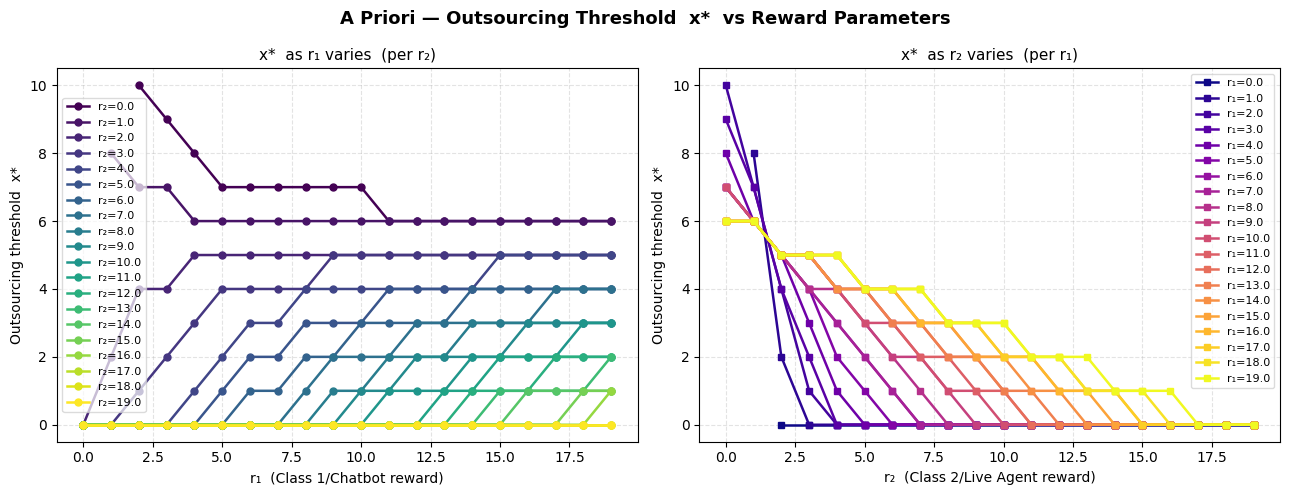

Running a posteriori sweep …


/var/folders/80/nt46s_zj37q09s9bvd_1j0vw0000gn/T/ipykernel_72089/2256237306.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


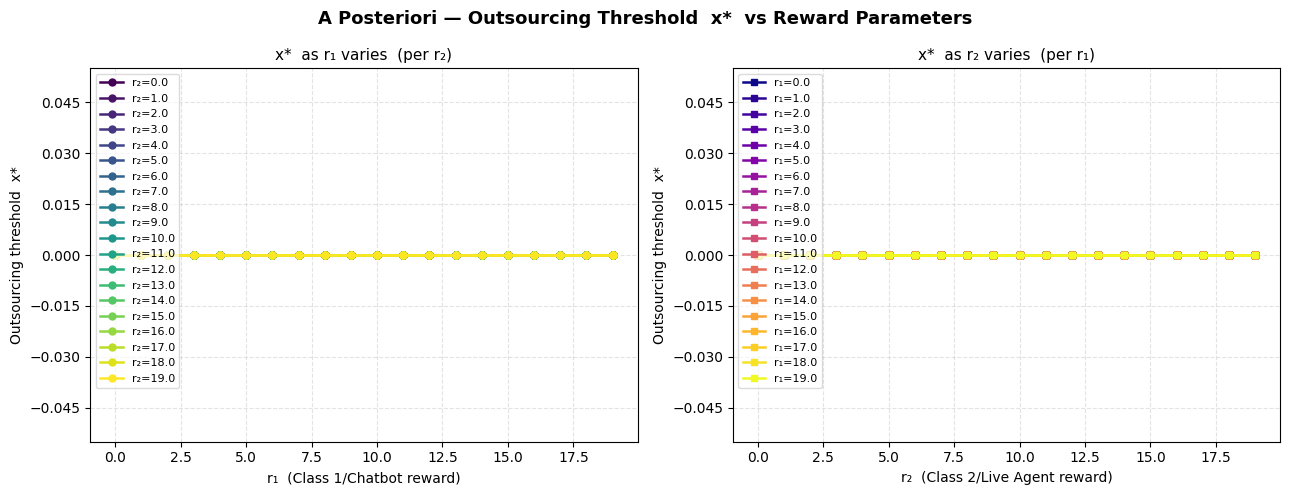

In [51]:
BASE = QueueingSystemParams(
    arrival_rate=0.6,
    num_servers=5,
    service_rate=0.5,
    class2_arrival_rate=0.3,
    class1_reward=5.0,
    class2_reward=2.0,
    outsourcing_cost=1.5,
    congestion_sensitivity=0.1,
    max_queue_length=15,
    convergence_tolerance=1e-6,
    max_iterations=2000,
)

R1_VALUES = range(0, 20, 1)
R2_VALUES = range(0, 20, 1)

print("Running a priori sweep …")
res_ap = run_sweep_parallel(_worker_apriori, BASE, R1_VALUES, R2_VALUES)
plot_policy_curves(res_ap, R1_VALUES, R2_VALUES,
                    title_prefix="A Priori",
                    filepath_prefix="policy_apriori")

print("Running a posteriori sweep …")
res_post = run_sweep_parallel(_worker_aposteriori, BASE, R1_VALUES, R2_VALUES)
plot_policy_curves(res_post, R1_VALUES, R2_VALUES,
                    title_prefix="A Posteriori",
                    filepath_prefix="policy_aposteriori")